# 05. 표현학습(SSL)과 도메인 적응

> **Day 01 — 제조 시계열 AI (5/5)**
> - 라벨 없이 설비 데이터의 지문을 뜨고(SSL), 공장이 달라져도 성능이 무너지지 않는 인코더를 만든다(도메인 적응).
> - **이 노트북이 회수하는 난제**
>   - ② 신규 설비 & Cold-Start — 라벨이 없다
>   - ③ Concept Drift & Sensor Shift — 분포가 틀어진다

---

## 구성 — NB04까지의 전제를 두 갈래로 깬다

NB04까지는 "정상 데이터가 충분히 있다"는 전제 위에 있었습니다. 이 노트북은 그 전제를 깹니다.

| | Part 1 — 라벨이 없다 | Part 2 — 공장이 바뀌었다 |
|---|---|---|
| 다루는 문제 | Cold-Start (라벨 0건) | 분포 시프트 (FD001 → FD003) |
| 방법 | 자기지도학습(SSL) · NT-Xent | 성능 붕괴 확인 → 분포 정렬(MMD) → 끝단 재학습(Linear Probe) |

| | |
|---|---|
| 쓰는 데이터 | C-MAPSS FD001(Source) → FD003(Target) — NB03와 같은 엔진, 운전 조건과 고장 모드가 다름 |
| 왜 이 데이터인가 | 도메인 시프트를 합성 조작 없이 실데이터로 확인할 수 있다. 추가 다운로드도 없다 |
| 이 노트북의 역할 | 난제 ②·③ 회수 — Day 1의 마지막 조각 |
| 앞에서 이어받는 것 | NB02의 슬라이딩 윈도우·시간 분할, NB03의 엔진 데이터와 Patch 개념 |
| 다음으로 넘기는 것 | 오늘 배운 내용 전부 — 마지막 토의 세션에서 압출기 100대 아키텍처 설계에 활용한다 |

직접 채우는 것은 손실 함수 두 개뿐입니다(NT-Xent, MMD). 인코더·학습 루프·데이터 파이프라인은
완성 코드로 제공됩니다 — 이후 모든 셀이 인코더에 의존하므로, 거기서 막히면 세션 전체가 멈추기 때문입니다.

---

## 목차

**[Part 1 — 자기지도학습으로 Cold-Start 넘기]**
1. Cold-Start 문제 재확인
2. 표현학습이란 — 설비 데이터의 지문을 뜨는 일
3. 시계열 데이터 증강과 제조 관점 필터
4. 대조학습의 구조 — 인코더와 Projection head
5. NT-Xent 손실 직접 구현
6. 사전학습 실행과 임베딩 품질 평가
7. 마스킹 복원 — 또 하나의 자기지도 방식

**[Part 2 — 도메인 적응으로 Drift 넘기]**
8. 성능 붕괴 실증 — FD001에서 FD003으로
9. 왜 무너지는가 — 잠재 공간을 겹쳐 보기
10. MMD 손실 직접 구현
11. Domain-invariant 인코더 학습
12. Linear Probing으로 회복하기
13. 확장 과제

In [1]:
# 공통 준비 — Colab / 로컬 양쪽에서 동작
import os, random, warnings
import numpy as np
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"PyTorch {torch.__version__} | device: {DEVICE}")
except ImportError:
    DEVICE = "cpu"
    print("PyTorch 미설치 — 다음 셀에서 설치합니다.")

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False
print(f"Colab 환경: {IN_COLAB}")

PyTorch 2.11.0+cpu | device: cpu
Colab 환경: True


In [2]:
# ══ 실습 자료 위치 — 강사가 배포한 주소로 이 한 줄만 맞추면 됩니다 ══════════
DATA_REPO = "https://raw.githubusercontent.com/leejiyoon52/ai-course/main/day1"

# Google Drive로 배포받았다면, 위 줄 대신 아래 두 줄의 주석을 푸십시오.
# from google.colab import drive; drive.mount("/content/drive")
# DATA_REPO = "file:///content/drive/MyDrive/ai-course/day1"
# ═══════════════════════════════════════════════════════════════════════

import os, shutil, urllib.request
os.environ["MFG_DATA_BASE"] = DATA_REPO          # loaders.py가 이 값을 읽습니다

for f in ["mfg_datagen.py", "loaders.py"]:
    if os.path.exists(f):
        continue
    src = f"{DATA_REPO}/modules/{f}"
    try:
        if src.startswith("file://"):
            shutil.copy(src[len("file://"):], f)
        else:
            urllib.request.urlretrieve(src, f)
        print(f"다운로드 완료: {f}")
    except Exception:
        print(f"⚠️ {f} 를 받지 못했습니다 — 왼쪽 파일 탭에 직접 업로드해 주세요")

import mfg_datagen
import loaders
print(f"실습 모듈 준비 완료 — 자료 위치: {DATA_REPO}")

다운로드 완료: mfg_datagen.py
다운로드 완료: loaders.py
실습 모듈 준비 완료 — 자료 위치: https://raw.githubusercontent.com/leejiyoon52/ai-course/main/day1


---
## 1. Cold-Start 문제 재확인 — 난제 ② 회수

> *가동 첫날의 신규 라인 — 정상이 뭔지도 아직 모릅니다.*

NB04에서는 "정상 데이터로 학습한다"는 전제 위에 있었습니다.
그런데 현장에는 그 전제가 성립하지 않는 순간이 반복해서 옵니다.

- 라인을 증설했습니다. 새 설비의 이력은 오늘부터 쌓입니다.
- 신제품 양산을 시작했습니다. 이 품종의 정상 파형을 아무도 모릅니다.
- 이력은 있는데 라벨이 없습니다. 불량 판정은 검사 공정에만 남아 있습니다.

라벨을 붙이려면 사람이 붙여야 하고, 그 사람은 생산 현장의 숙련자입니다.
라벨에는 비용이 따릅니다. 그래서 질문이 바뀝니다 —
"라벨 없이 배울 수 있는 것은 무엇인가."

In [3]:
# 항공기 엔진 데이터 로드 — NB03와 같은 데이터, 이번엔 라벨을 감춘다
"""따라하기"""
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["axes.grid"] = True

SENSORS = ["s2", "s3", "s4", "s7", "s11", "s12", "s15", "s21"]
WIN, NEAR = 30, 30                       # 윈도우 30사이클, RUL 30 이하를 '고장 임박'으로 본다

src_raw, _, _ = loaders.load_cmapss("FD001")
src = loaders.add_rul(src_raw, cap=125)
print(f"Source(FD001): {src.shape} | 엔진 {src['unit'].nunique()}대")
print("오늘은 이 라벨(RUL)을 '없는 셈 치고' 인코더를 학습시킨 뒤, 마지막에만 조금 꺼내 씁니다.")

✅ C-MAPSS FD001 실데이터 로드 완료 (train (20631, 26), test (13096, 26))
Source(FD001): (20631, 27) | 엔진 100대
오늘은 이 라벨(RUL)을 '없는 셈 치고' 인코더를 학습시킨 뒤, 마지막에만 조금 꺼내 씁니다.


In [4]:
# 윈도우 만들기 — NB02의 슬라이딩 윈도우 재사용
"""따라하기"""
import numpy as np

def make_windows(df, sensors, win=WIN, stride=2):
    X, y, unit_of = [], [], []
    for u in df["unit"].unique():
        g = df[df["unit"] == u]
        a, r = g[sensors].values, g["RUL"].values
        for i in range(0, len(g) - win, stride):
            X.append(a[i:i + win])
            y.append(int(r[i + win - 1] <= NEAR))       # 1 = 고장 임박
            unit_of.append(u)                            # 이 윈도우가 나온 엔진
    return np.array(X, dtype=np.float32), np.array(y), np.array(unit_of)

Xs_raw, ys, us = make_windows(src, SENSORS)
print(f"Source 윈도우 {Xs_raw.shape} | 고장 임박 비율 {ys.mean():.3f}")
print(f"엔진 {len(np.unique(us))}대에서 나왔습니다 — 평가는 엔진 단위로 나눕니다.")
print(f"※ stride=2, 윈도우 길이 {WIN} → 이웃 윈도우가 대부분 겹칩니다.")
print("  무작위로 나누면 거의 같은 윈도우가 학습과 평가에 나뉘어 들어갑니다(NB02의 누수).")

Source 윈도우 (8841, 30, 8) | 고장 임박 비율 0.170
엔진 100대에서 나왔습니다 — 평가는 엔진 단위로 나눕니다.
※ stride=2, 윈도우 길이 30 → 이웃 윈도우가 대부분 겹칩니다.
  무작위로 나누면 거의 같은 윈도우가 학습과 평가에 나뉘어 들어갑니다(NB02의 누수).


In [5]:
# 스케일링 — Source 통계로만 fit (NB02 원칙)
"""따라하기"""
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(Xs_raw.reshape(-1, len(SENSORS)))
def norm(X):
    return scaler.transform(X.reshape(-1, len(SENSORS))).reshape(X.shape).astype(np.float32)

Xs = norm(Xs_raw)
print(f"정규화 후 평균 {Xs.mean():.4f} / 표준편차 {Xs.std():.4f}")

정규화 후 평균 -0.0000 / 표준편차 1.0000


In [6]:
# 라벨을 다 붙이려면 얼마나 드는가 — 숫자로 체감
n_win = len(Xs)
SEC_PER_LABEL = 30          # 윈도우 하나 판정에 숙련자 30초라 가정
hours = n_win * SEC_PER_LABEL / 3600
print(f"윈도우 {n_win:,}개 × {SEC_PER_LABEL}초 = 약 {hours:.0f}시간 ({hours / 8:.0f} 근무일)")
print("설비 한 대, 한 품종 기준입니다. 라인 전체·전 품종으로 곱하면 현실적으로 불가능합니다.")
print("\n그래서 순서를 바꿉니다 — 라벨 없이 표현을 먼저 배우고, 라벨은 마지막에 조금만 씁니다.")

윈도우 8,841개 × 30초 = 약 74시간 (9 근무일)
설비 한 대, 한 품종 기준입니다. 라인 전체·전 품종으로 곱하면 현실적으로 불가능합니다.

그래서 순서를 바꿉니다 — 라벨 없이 표현을 먼저 배우고, 라벨은 마지막에 조금만 씁니다.


---
## 2. 표현학습이란 — 설비 데이터의 지문을 뜨는 일

표현학습(Representation Learning)은 원시 파형을 고정 길이 벡터(임베딩)로 바꾸는 법을
배우는 일입니다. 설비 상태를 나타내는 좌표를 만드는 것이라고 생각하면 됩니다 —
비슷한 상태는 가까운 자리에 놓입니다.

**좋은 표현의 조건 세 가지**

| 조건 | 의미 | 제조에서의 예 |
|---|---|---|
| 구별력 | 다른 상태는 다른 좌표로 | 정상 가공과 공구 마모 구간이 떨어져 있어야 |
| 불변성 | 본질이 같으면 같은 좌표로 | 같은 정상 운전이면 미세한 노이즈에 흔들리지 않아야 |
| 전이성 | 다른 과제·설비에도 쓸 수 있어야 | 이상탐지용으로 뜬 지문이 수명 예측에도 도움이 되어야 |

자기지도학습(Self-Supervised Learning, SSL)은 라벨 대신 데이터 자신에게서 문제를 만들어
이 표현을 배웁니다. 오늘 다루는 방식은 두 가지입니다.

1. 대조학습(Contrastive) — 같은 설비의 다른 순간은 가깝게, 다른 설비는 멀게 배치
2. 마스킹 복원(Masked Reconstruction) — 신호 일부를 가리고 나머지 문맥으로 복원

---
## 3. 시계열 데이터 증강과 제조 관점 필터

대조학습은 "같은 것의 두 가지 모습"이 필요합니다. 그 두 모습을 증강(augmentation)으로 만듭니다.
단, 물리적으로 가능한 변형만 써야 합니다.

In [7]:
# 시계열 증강 3종 — Jittering / Scaling / Time Warping
"""따라하기"""
def jitter(x, sigma=0.05, rng=None):
    """센서 노이즈 흉내 — 측정 오차 수준의 흔들림"""
    rng = rng or np.random.default_rng(SEED)
    return (x + rng.normal(0, sigma, x.shape)).astype(np.float32)

def scaling(x, sigma=0.05, rng=None):
    """센서 게인 편차 흉내 — 채널마다 배율을 조금씩 다르게"""
    rng = rng or np.random.default_rng(SEED)
    factor = rng.normal(1.0, sigma, (x.shape[0], 1, x.shape[2]))
    return (x * factor).astype(np.float32)

def time_warp(x, max_shift=3, rng=None):
    """진행 속도 편차 흉내 — 시간축을 조금 당기거나 민다"""
    rng = rng or np.random.default_rng(SEED)
    out = np.empty_like(x)
    for i in range(len(x)):
        shift = int(rng.integers(-max_shift, max_shift + 1))
        out[i] = np.roll(x[i], shift, axis=0)
    return out.astype(np.float32)

demo = Xs[:4]
print(f"원본 {demo.shape} → jitter {jitter(demo).shape}, scaling {scaling(demo).shape}, "
      f"time_warp {time_warp(demo).shape}")

원본 (4, 30, 8) → jitter (4, 30, 8), scaling (4, 30, 8), time_warp (4, 30, 8)


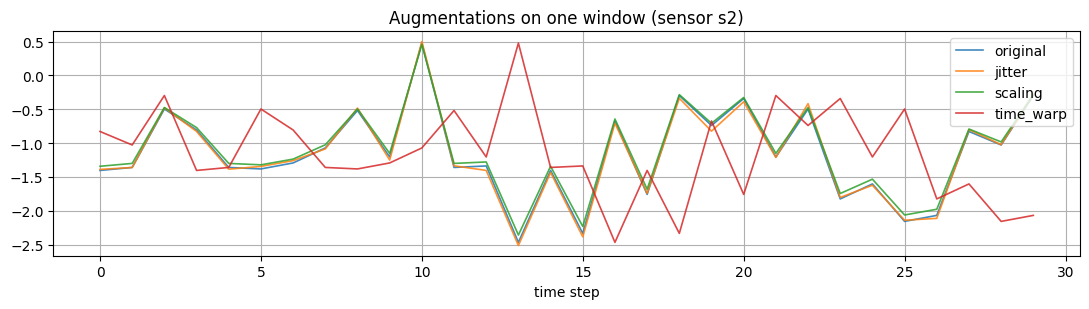

네 곡선이 '같은 상태의 다른 모습'으로 보여야 합니다. 이것이 대조학습의 positive pair가 됩니다.


In [8]:
# 증강이 파형을 어떻게 바꾸는지 눈으로 확인 — 형태는 유지, 세부만 흔들린다
rng_demo = np.random.default_rng(SEED)
one = Xs[100:101]
variants = {"original": one, "jitter": jitter(one, rng=rng_demo),
            "scaling": scaling(one, rng=rng_demo), "time_warp": time_warp(one, rng=rng_demo)}

fig, ax = plt.subplots(figsize=(11, 3.2))
for name, v in variants.items():
    ax.plot(v[0, :, 0], label=name, lw=1.2, alpha=0.85)
ax.set_title("Augmentations on one window (sensor s2)")
ax.set_xlabel("time step"); ax.legend()
plt.tight_layout(); plt.show()
print("네 곡선이 '같은 상태의 다른 모습'으로 보여야 합니다. 이것이 대조학습의 positive pair가 됩니다.")

### 제조 관점 필터 — 물리적으로 불가능한 증강은 해롭습니다

이미지 증강을 그대로 옮기면 안 됩니다. 제조 신호에는 물리 법칙이 있습니다.

| 증강 | 제조에서 타당한가 |
|---|---|
| Jittering (약한 노이즈) | ✅ 센서 측정 오차는 실제로 존재합니다 |
| Scaling (채널별 소폭) | ✅ 센서 게인·설치 편차를 흉내 냅니다 |
| Time Warping (소폭) | ✅ 사이클 속도 편차는 실제로 생깁니다 |
| **Permutation (구간 순서 섞기)** | ❌ 사출 공정에서 사출→보압→냉각 순서가 바뀌는 일은 없습니다 |
| **과도한 Scaling (×2 이상)** | ❌ 온도가 두 배가 되면 그건 다른 물리 상태입니다 |
| **좌우 반전(flip)** | ❌ 시간은 거꾸로 흐르지 않습니다 |

> **현장 노트**
> 증강 목록은 논문에서 베끼는 것이 아니라 **공정 엔지니어와 함께 정하는 것**입니다.
> 저는 증강 후보를 표로 만들어 "이 변형이 실제 라인에서 일어날 수 있습니까"를 묻습니다.
> 이 질문 한 번으로 후보의 절반이 걸러집니다. 물리적으로 불가능한 변형을 positive pair로
> 묶으면, 모델은 "달라도 같다"는 잘못된 불변성을 배웁니다.

**증강을 아예 피하는 계열도 있습니다.** TS2Vec 같은 방법은 어떤 증강이 타당한지 정하기 어렵다는
점을 인정하고, 대신 **랜덤 크롭과 타임스탬프 마스킹**으로 positive pair를 만듭니다.
증강 설계가 어려운 공정에서는 이쪽이 안전한 선택이 됩니다. (개념만 짚고 넘어갑니다)

---
## 4. 대조학습의 구조

```
윈도우 x ──┬─ 증강 A ─→ 인코더 f ─→ z1 ─→ Projection g ─→ p1 ┐
           └─ 증강 B ─→ 인코더 f ─→ z2 ─→ Projection g ─→ p2 ┘  → 서로 끌어당김 (positive)

같은 배치의 다른 윈도우들 ─────────────────────────────→ 밀어냄 (negative)
```

- **인코더 f**: 1D-CNN. 실제로 우리가 쓰고 싶은 지문을 만듭니다. 학습 후 **이것만 남깁니다.**
- **Projection head g**: 손실 계산 전용 보조 장치. 학습이 끝나면 **버립니다.**
  대조 손실에 맞춰 표현이 지나치게 특화되는 것을 g가 흡수해 주기 때문입니다.

In [ ]:
# 1D-CNN 인코더와 Projection head — 이후 전 셀의 의존성
"""따라하기"""
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class Encoder(nn.Module):
    """(B, L, C) → (B, dim) 설비 상태의 지문"""
    def __init__(self, c, dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(64, dim)

    def forward(self, x):
        return self.fc(self.net(x.transpose(1, 2)).squeeze(-1))

class Projection(nn.Module):
    """손실 계산 전용 — 학습이 끝나면 버린다"""
    def __init__(self, dim=64, out=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, dim), nn.ReLU(), nn.Linear(dim, out))

    def forward(self, z):
        return self.net(z)

enc_demo = Encoder(len(SENSORS))
print(f"인코더 파라미터 {sum(p.numel() for p in enc_demo.parameters()):,}")
print(f"윈도우 {tuple(Xs[:4].shape)} → 임베딩 {tuple(enc_demo(torch.tensor(Xs[:4])).shape)}")

---
## 5. NT-Xent 손실 직접 구현

**NT-Xent(Normalized Temperature-scaled Cross Entropy)** 는 대조학습의 표준 손실입니다.
수식과 코드를 나란히 두고 봅니다.

$$\ell_{i} = -\log \frac{\exp\!\big(\text{sim}(p_i, p_{j(i)}) / \tau\big)}
{\sum_{k \neq i} \exp\!\big(\text{sim}(p_i, p_k) / \tau\big)}$$

- $\text{sim}$: 코사인 유사도 → 벡터를 L2 정규화한 뒤 내적하면 됩니다
- $j(i)$: $i$의 짝(같은 원본에서 나온 다른 증강본)
- $\tau$(temperature): 작을수록 어려운 negative에 집중합니다

**핵심 아이디어**: 2N개 벡터의 유사도 행렬을 만든 뒤,
"내 짝을 정답으로 하는 분류 문제"로 바꿔 cross-entropy를 먹입니다.

In [ ]:
# NT-Xent 손실 — 유사도 행렬에서 positive만 골라낸다
"""직접구현"""
def nt_xent(z1, z2, tau=0.5):
    z = torch.cat([z1, z2], dim=0)                 # (2N, d) 위아래로 이어붙임
    z = F.normalize(z, dim=1)                      # 코사인 유사도를 위한 L2 정규화
    sim = z @ z.T / tau                            # (2N, 2N) 유사도 행렬
    sim.fill_diagonal_(-1e9)                       # 자기 자신은 제외
    N = z1.size(0)
    targets = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)]).to(z.device)
    return F.cross_entropy(sim, targets)           # "내 짝 맞히기" 분류 문제

# 검증: 짝이 완전히 같으면 손실이 작고, 무작위면 커야 한다
torch.manual_seed(SEED)
a = torch.randn(16, 32)
print(f"짝이 동일할 때  : {nt_xent(a, a.clone()).item():.4f}")
print(f"짝이 무작위일 때: {nt_xent(a, torch.randn(16, 32)).item():.4f}")
print("→ 동일한 쪽이 확실히 작아야 구현이 맞습니다.")

In [ ]:
# 사전학습 실행 — 라벨을 단 한 번도 쓰지 않는다
"""따라하기"""
# 학습 약 60초 소요 (T4 기준)
import time

def pretrain(X_src, X_tgt=None, lam=0.0, epochs=6, seed=SEED, mmd_fn=None):
    """대조학습으로 인코더를 사전학습한다. lam>0 이면 MMD 항을 더한다(Part 2에서 사용)."""
    torch.manual_seed(seed)
    enc, proj = Encoder(len(SENSORS)).to(DEVICE), Projection().to(DEVICE)
    opt = torch.optim.Adam(list(enc.parameters()) + list(proj.parameters()), lr=1e-3)
    rng = np.random.default_rng(seed)
    dl = DataLoader(TensorDataset(torch.tensor(X_src)), batch_size=128, shuffle=True)
    Xt_t = torch.tensor(X_tgt).to(DEVICE) if X_tgt is not None else None

    for ep in range(epochs):
        enc.train(); tot = 0.0
        for (xb,) in dl:
            xb = xb.to(DEVICE)
            v1 = torch.tensor(jitter(scaling(xb.cpu().numpy(), rng=rng), rng=rng)).to(DEVICE)
            v2 = torch.tensor(time_warp(jitter(xb.cpu().numpy(), rng=rng), rng=rng)).to(DEVICE)
            loss = nt_xent(proj(enc(v1)), proj(enc(v2)))
            if Xt_t is not None and lam > 0:
                idx = rng.choice(len(Xt_t), len(xb), replace=False)
                loss = loss + lam * mmd_fn(enc(xb), enc(Xt_t[idx]))   # 라벨 없는 Target X만 사용
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()
        print(f"epoch {ep + 1}/{epochs} | loss {tot / len(dl):.4f}")
    return enc

t0 = time.time()
encoder = pretrain(Xs, epochs=6)
print(f"사전학습 완료 — {time.time() - t0:.0f}초, 라벨 사용 0건")

In [ ]:
# 체크포인트 로드 — 없으면 방금 학습한 데모 인코더로 진행
"""따라하기"""
state = loaders.load_checkpoint("d1_05_ssl_encoder")
if state is not None:
    encoder.load_state_dict(state)
    print("체크포인트를 반영했습니다 — 이후 t-SNE 품질이 안정적입니다.")
encoder.eval()

def embed(enc, X, bs=512):
    enc.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            out.append(enc(torch.tensor(X[i:i + bs]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

Zs = embed(encoder, Xs)
print(f"임베딩 {Zs.shape} — 윈도우 하나가 {Zs.shape[1]}차원 좌표가 되었습니다")

---
## 6. 임베딩 품질 평가

표현을 학습했으니 잘 학습됐는지 확인해야 합니다. 두 가지로 봅니다.

1. **t-SNE 시각화** — 고차원 임베딩을 2차원으로 눌러 눈으로 확인
2. **Linear Probe** — 인코더를 얼려 두고 끝단에 선형 분류기만 붙여 성능 측정.
   *잘 뜬 지문 위에 이름표만 새로 붙이기* 입니다.
   표현이 좋으면 선형 분류기 하나로도 잘 나뉩니다.

In [ ]:
# t-SNE로 임베딩 공간 들여다보기
"""따라하기"""
from sklearn.manifold import TSNE

rng_v = np.random.default_rng(SEED)
sub = rng_v.choice(len(Zs), 1500, replace=False)          # 속도를 위해 일부만
emb2d = TSNE(n_components=2, random_state=SEED, init="pca",
             perplexity=30).fit_transform(Zs[sub])

fig, ax = plt.subplots(figsize=(5.2, 4.6))
for v, name, color in [(0, "healthy", "tab:blue"), (1, "near failure", "tab:red")]:
    m = ys[sub] == v
    ax.scatter(emb2d[m, 0], emb2d[m, 1], s=5, alpha=0.5, label=name, color=color)
ax.set_title("SSL embedding (t-SNE)")
ax.legend(); plt.tight_layout(); plt.show()
print("라벨을 한 번도 안 썼는데 고장 임박 구간이 한쪽으로 모입니다 —")
print("열화가 신호에 남긴 흔적을 인코더가 스스로 찾아낸 것입니다.")

In [ ]:
# 임베딩이 실제로 무엇을 잡았는가 — 좌표만으로 군집을 나눠 평균 잔여수명을 본다
from sklearn.cluster import KMeans

rul_all = np.concatenate([
    src[src["unit"] == u]["RUL"].values[WIN - 1::2][:n]
    for u, n in zip(src["unit"].unique(),
                    [len(range(0, len(src[src["unit"] == u]) - WIN, 2))
                     for u in src["unit"].unique()])])

km = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(Zs)
prof = pd.DataFrame({"군집": range(4)})
prof["윈도우 수"] = [int((km.labels_ == k).sum()) for k in range(4)]
prof["평균 RUL"] = [round(float(rul_all[km.labels_ == k].mean()), 1) for k in range(4)]
prof["고장 임박 비율"] = [round(float(ys[km.labels_ == k].mean()), 3) for k in range(4)]
print(prof.sort_values("평균 RUL").to_string(index=False))
print("\n군집은 라벨 없이 좌표만으로 나눈 것입니다. 그런데 군집마다 평균 잔여수명이 뚜렷이 갈립니다.")
print("→ 인코더가 만든 좌표축 하나가 사실상 '열화 정도'를 담고 있다는 뜻입니다.")

In [ ]:
# Linear Probe — 인코더는 얼리고 선형 분류기만 학습
"""따라하기"""
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def linear_probe(Z, y, n_label, groups=None, seed=SEED, train_frac=0.7):
    """n_label개 라벨만 써서 선형 분류기를 학습하고, 처음 보는 엔진에서 평가한다.

    groups: 각 윈도우가 나온 엔진 ID. 엔진 단위로 먼저 나눈 뒤 라벨을 뽑는다.
            윈도우가 겹치므로 무작위로 나누면 같은 구간이 학습·평가에 함께 들어간다.
    """
    rng = np.random.default_rng(seed)
    if groups is None:
        groups = np.zeros(len(Z), dtype=int)
    uniq = np.unique(groups)
    tr_g = set(uniq[:max(1, int(len(uniq) * train_frac))])     # 앞쪽 엔진 = 학습용
    in_tr = np.isin(groups, list(tr_g))
    pool, hold = np.where(in_tr)[0], np.where(~in_tr)[0]
    if len(hold) == 0:                                          # 그룹이 하나뿐이면 인덱스로 분할
        cut = int(len(Z) * train_frac)
        pool, hold = np.arange(cut), np.arange(cut, len(Z))
    idx = rng.choice(pool, min(n_label, len(pool)), replace=False)
    clf = LogisticRegression(max_iter=2000).fit(Z[idx], y[idx])
    p = clf.predict(Z[hold])
    return accuracy_score(y[hold], p), f1_score(y[hold], p, zero_division=0)

acc, f1 = linear_probe(Zs, ys, n_label=200, groups=us)
print(f"라벨 200개만으로 → 정확도 {acc:.3f} / F1 {f1:.3f}")
print("인코더는 전혀 건드리지 않았습니다. 선형 분류기의 계수만 학습했습니다.")

In [ ]:
# 사전학습이 정말 기여했는가 — 무작위 초기화 인코더와 비교
"""따라하기"""
torch.manual_seed(SEED)
enc_random = Encoder(len(SENSORS)).to(DEVICE)          # 학습을 전혀 하지 않은 인코더
Zs_rand = embed(enc_random, Xs)
Xs_flat = Xs.reshape(len(Xs), -1)                      # 원시 파형을 그대로 편 것

rows = []
for n_label in [50, 200, 1000, len(Xs) // 2]:
    a1, f1_ = linear_probe(Zs, ys, n_label, groups=us)
    a2, f2_ = linear_probe(Zs_rand, ys, n_label, groups=us)
    a3, f3_ = linear_probe(Xs_flat, ys, n_label, groups=us)
    rows.append({"라벨 수": n_label, "SSL F1": round(f1_, 3),
                 "무작위 인코더 F1": round(f2_, 3), "원시 파형 F1": round(f3_, 3)})
curve = pd.DataFrame(rows)
print(curve.to_string(index=False))

In [ ]:
# 라벨 수에 따른 성능 곡선 — SSL의 가치가 어디서 나오는가
fig, ax = plt.subplots(figsize=(9, 3.5))
for col, style in [("SSL F1", "-o"), ("무작위 인코더 F1", "--s"), ("원시 파형 F1", ":^")]:
    ax.plot(curve["라벨 수"], curve[col], style, ms=5,
            label={"SSL F1": "SSL encoder", "무작위 인코더 F1": "random encoder",
                   "원시 파형 F1": "raw waveform"}[col])
ax.set_xscale("log"); ax.set_xlabel("number of labels (log scale)"); ax.set_ylabel("F1")
ax.set_title("Where self-supervised pretraining pays off")
ax.legend(); plt.tight_layout(); plt.show()

gap_small = curve.iloc[0]["SSL F1"] - curve.iloc[0]["무작위 인코더 F1"]
gap_large = curve.iloc[-1]["SSL F1"] - curve.iloc[-1]["무작위 인코더 F1"]
print(f"라벨 {curve.iloc[0]['라벨 수']}개일 때 SSL 우위: {gap_small:+.3f}")
print(f"라벨 {curve.iloc[-1]['라벨 수']}개일 때 SSL 우위: {gap_large:+.3f}")

### 곡선을 읽는 법 — 사전학습은 언제 값어치를 하는가

- **라벨이 적을수록 SSL의 우위가 큽니다.** 라벨이 충분해지면 무작위 인코더도 따라옵니다.
  Cold-Start는 정확히 "라벨이 적은 구간"이고, 거기가 SSL의 자리입니다.
- **원시 파형이 만만치 않은 베이스라인입니다.** C-MAPSS 센서값은 이미 단조 열화 추세를
  담고 있어 선형 분류기가 바로 써먹을 수 있습니다.

> **현장 노트**
> *베이스라인은 신입 작업자의 감(勘)입니다 — 이걸 못 이기면 모델은 필요 없습니다.*
> SSL 파이프라인을 다 짜 놓고 "원시 피처 로지스틱 회귀"에 지는 경우를 여러 번 봤습니다.
> 채널이 8개뿐이고 신호가 이미 깔끔하면 표현학습이 얹어 줄 것이 많지 않습니다.
> SSL이 확실히 이기는 조건은 따로 있습니다 — **채널이 수십 개 이상**이거나,
> **라벨이 극히 적거나**, **여러 설비·품종으로 전이**해야 할 때입니다.
> 그래서 저는 SSL을 붙이기 전에 항상 원시 피처 베이스라인부터 찍어 둡니다.

---
## 7. 마스킹 복원 — 또 하나의 자기지도 방식

대조학습이 "두 모습을 가깝게 배치하는" 방식이라면, 마스킹 복원은
신호 일부를 가리고 나머지 문맥으로 복원하게 하는 방식입니다.

NB03에서 만든 Patch 개념을 그대로 재사용합니다. 윈도우를 패치로 나누고,
일부를 가린 뒤 나머지 문맥으로 복원하게 시킵니다.
가린 자리를 맞히려면 신호의 구조를 이해해야 하므로, 그 과정에서 표현이 학습됩니다.

| | 대조학습 | 마스킹 복원 |
|---|---|---|
| 필요한 것 | 타당한 증강 설계 | 마스킹 비율만 정하면 됨 |
| 배우는 것 | 전역적 유사성 (윈도우 단위) | 국소 구조 (패치 단위) |
| 제조 적용 | 증강이 물리적으로 타당해야 | 증강 고민이 없어 적용이 수월 |

In [ ]:
# 마스킹 복원 데모 — 패치 일부를 가리고 복원시킨다
"""따라하기"""
# 학습 약 30초 소요 (T4 기준)
PATCH = 5
N_PATCH = WIN // PATCH

class MaskedModel(nn.Module):
    def __init__(self, c, patch=PATCH, n_patch=N_PATCH, dim=64):
        super().__init__()
        self.patch, self.n_patch, self.c = patch, n_patch, c
        self.proj = nn.Linear(patch * c, dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.body = nn.Sequential(nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
        self.head = nn.Linear(dim, patch * c)

    def forward(self, x, mask):                       # x:(B,L,C)  mask:(B,n_patch) True=가림
        B = x.size(0)
        p = x.view(B, self.n_patch, self.patch * self.c)
        t = self.proj(p)
        t = torch.where(mask.unsqueeze(-1), self.mask_token.expand_as(t), t)
        return self.head(self.body(t)), p             # 복원 결과, 정답 패치

torch.manual_seed(SEED)
mm = MaskedModel(len(SENSORS)).to(DEVICE)
opt_m = torch.optim.Adam(mm.parameters(), lr=1e-3)
dl_m = DataLoader(TensorDataset(torch.tensor(Xs)), batch_size=128, shuffle=True)

for ep in range(3):
    mm.train(); tot = 0.0
    for (xb,) in dl_m:
        xb = xb.to(DEVICE)
        mask = torch.rand(xb.size(0), N_PATCH, device=DEVICE) < 0.4      # 40% 가림
        pred, target = mm(xb, mask)
        loss = ((pred - target) ** 2)[mask].mean()                        # 가린 자리만 채점
        opt_m.zero_grad(); loss.backward(); opt_m.step(); tot += loss.item()
    print(f"epoch {ep + 1}/3 | 복원 손실 {tot / len(dl_m):.4f}")

In [ ]:
# 가린 자리를 얼마나 채웠는지 눈으로 확인
mm.eval()
with torch.no_grad():
    xb = torch.tensor(Xs[:1]).to(DEVICE)
    mask = torch.zeros(1, N_PATCH, dtype=torch.bool, device=DEVICE)
    mask[0, 2:4] = True                                       # 가운데 패치 2개를 가린다
    pred, target = mm(xb, mask)

orig = target[0].cpu().numpy().reshape(N_PATCH, PATCH, len(SENSORS))[:, :, 0].ravel()
recon = pred[0].cpu().numpy().reshape(N_PATCH, PATCH, len(SENSORS))[:, :, 0].ravel()

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(orig, label="original", lw=1.5)
ax.plot(recon, "--", label="reconstructed", lw=1.2)
ax.axvspan(2 * PATCH, 4 * PATCH, color="red", alpha=0.15, label="masked")
ax.set_title("Masked patch reconstruction (sensor s2)")
ax.legend(); plt.tight_layout(); plt.show()
print("붉은 구간이 모델이 보지 못한 자리입니다. 앞뒤 흐름만으로 여기를 메우는 것이 학습 신호입니다.")

---
# Part 2 — 도메인 적응으로 Drift 넘기

## 8. 성능 붕괴 실증 — 난제 ③ 회수

> *어제까지 맞던 저울이 오늘 영점이 틀어진 것.*

**해법보다 문제를 먼저 봅니다.** 순서가 중요합니다.

- **Source**: C-MAPSS **FD001** — 지금까지 쓴 데이터
- **Target**: C-MAPSS **FD003** — **같은 엔진**인데 **운전 조건과 고장 모드가 다릅니다**

합성으로 조작한 시프트가 아닙니다. 실데이터가 원래 그렇게 기록되어 있습니다.
현장으로 옮기면 이렇습니다 — 부품을 교체했다, 공정 조건을 바꿨다, 계절이 바뀌었다.

In [ ]:
# Target 도메인(FD003) 로드 — Source와 완전히 같은 처리
"""따라하기"""
tgt_raw, _, _ = loaders.load_cmapss("FD003")
tgt = loaders.add_rul(tgt_raw, cap=125)
Xt_raw, yt, ut = make_windows(tgt, SENSORS)
Xt = norm(Xt_raw)                                    # ★ Source 스케일러를 그대로 적용

print(f"Target(FD003) 윈도우 {Xt.shape} | 고장 임박 비율 {yt.mean():.3f}")
print(f"Source 대비 — 윈도우 {len(Xt) / len(Xs):.2f}배, 임박 비율 {yt.mean() - ys.mean():+.3f}")
print("\n배포 상황을 그대로 흉내 냅니다: 새 공장의 데이터에 우리 스케일러·모델을 그대로 얹습니다.")

In [ ]:
# 시프트의 원인을 센서 단위로 — 어느 채널이 얼마나 틀어졌는가
shift = pd.DataFrame({
    "Source 평균": Xs.reshape(-1, len(SENSORS)).mean(0),
    "Target 평균": Xt.reshape(-1, len(SENSORS)).mean(0),
}, index=SENSORS)
shift["차이(σ 단위)"] = (shift["Target 평균"] - shift["Source 평균"]).round(2)
print(shift.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(SENSORS, shift["차이(σ 단위)"])
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("mean shift (in source sigma)")
ax.set_title("Which sensors moved between FD001 and FD003")
plt.tight_layout(); plt.show()
print("\nSource 기준으로 정규화했으므로 0에서 멀수록 '우리가 알던 정상'에서 벗어난 채널입니다.")
print("현장에서는 이 표가 곧 점검 대상 목록이 됩니다 — 센서 교정부터 볼지, 공정 조건을 볼지.")

In [ ]:
# 붕괴 실증 — 같은 인코더, 같은 분류기를 Target에 그대로 적용
"""따라하기"""
Zt = embed(encoder, Xt)

def transfer_eval(Z_src, y_src, Z_tgt, y_tgt, n_label=1000, seed=SEED):
    """Source 라벨로 학습한 선형 분류기를 Target에 그대로 적용한다."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Z_src), n_label, replace=False)
    clf = LogisticRegression(max_iter=2000).fit(Z_src[idx], y_src[idx])
    hold = np.setdiff1d(np.arange(len(Z_src)), idx)
    ps, pt = clf.predict(Z_src[hold]), clf.predict(Z_tgt)
    return (f1_score(y_src[hold], ps, zero_division=0),
            f1_score(y_tgt, pt, zero_division=0),
            accuracy_score(y_tgt, pt))

f1_src, f1_tgt, acc_tgt = transfer_eval(Zs, ys, Zt, yt)
print(f"Source(FD001) F1 : {f1_src:.3f}")
print(f"Target(FD003) F1 : {f1_tgt:.3f}   ← 그대로 옮겼을 때")
print(f"성능 하락        : {100 * (f1_tgt - f1_src) / f1_src:+.1f}%")
print("\n코드는 한 줄도 바뀌지 않았습니다. 데이터가 온 공장이 달라졌을 뿐입니다.")

---
## 9. 왜 무너지는가 — 잠재 공간을 겹쳐 보기

분류기는 Source 임베딩 위에 경계선을 그었습니다.
Target 임베딩이 **다른 자리에 놓여 있다면**, 그 경계선은 엉뚱한 곳을 자르게 됩니다.
눈으로 확인합니다.

In [ ]:
# Source와 Target 임베딩을 한 평면에 겹쳐 그린다
"""따라하기"""
def tsne_overlay(Z_src, Z_tgt, title, n=800, seed=SEED):
    rng = np.random.default_rng(seed)
    i1 = rng.choice(len(Z_src), n, replace=False)
    i2 = rng.choice(len(Z_tgt), n, replace=False)
    both = np.vstack([Z_src[i1], Z_tgt[i2]])
    e = TSNE(n_components=2, random_state=seed, init="pca", perplexity=30).fit_transform(both)
    return e[:n], e[n:], title

es, et, ttl = tsne_overlay(Zs, Zt, "Before domain adaptation")
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(es[:, 0], es[:, 1], s=6, alpha=0.5, label="Source (FD001)")
ax.scatter(et[:, 0], et[:, 1], s=6, alpha=0.5, label="Target (FD003)")
ax.set_title(ttl); ax.legend(); plt.tight_layout(); plt.show()
print("두 덩어리가 갈라져 있으면, Source 위에 그은 경계선은 Target에서 의미를 잃습니다.")

In [ ]:
# 눈이 아니라 숫자로 — 두 도메인 임베딩의 평균 거리
d_mean = np.linalg.norm(Zs.mean(0) - Zt.mean(0))
within = np.linalg.norm(Zs[:500] - Zs.mean(0), axis=1).mean()
print(f"도메인 간 중심 거리      : {d_mean:.3f}")
print(f"Source 내부 평균 산포    : {within:.3f}")
print(f"비율(도메인 간 / 내부)   : {d_mean / within:.2f}")
print("\n이 비율이 클수록 '다른 공장'이라는 뜻입니다. 다음 절에서 이 거리를 손실로 만듭니다.")

---
## 10. MMD 손실 직접 구현

**MMD(Maximum Mean Discrepancy)** 는 *두 무리가 같은 자리에 서 있는지 재는 줄자* 입니다.
두 분포에서 뽑은 표본만으로 분포 간 거리를 잽니다.

$$\text{MMD}^2(X, Y) = \mathbb{E}[k(x, x')] + \mathbb{E}[k(y, y')] - 2\,\mathbb{E}[k(x, y)]$$

- $k$: 가우시안 커널. 두 점이 가까우면 1, 멀면 0에 가깝습니다
- **세 항의 의미**: (X끼리 얼마나 뭉쳤나) + (Y끼리 얼마나 뭉쳤나) − 2×(X와 Y가 얼마나 섞였나)
- 두 분포가 같으면 세 항이 상쇄되어 0에 가까워집니다
- **라벨이 전혀 필요 없습니다.** Target의 X만 있으면 됩니다 — Cold-Start 상황에 딱 맞습니다

In [ ]:
# MMD 손실 — 가우시안 커널 기반 분포 거리, 3항의 합
"""직접구현"""
def mmd_loss(x, y, sigmas=(1, 2, 4, 8)):
    """x, y: (B, d) 두 도메인의 임베딩 → 스칼라 거리"""
    def kernel(a, b):
        d2 = torch.cdist(a, b) ** 2                          # 모든 쌍의 제곱 거리
        return sum(torch.exp(-d2 / (2 * s ** 2)) for s in sigmas) / len(sigmas)
    return kernel(x, x).mean() + kernel(y, y).mean() - 2 * kernel(x, y).mean()

# 검증: 같은 분포끼리는 0에 가깝고, 멀어질수록 커져야 한다
torch.manual_seed(SEED)
a = torch.randn(256, 16)
print(f"같은 분포        : {mmd_loss(a, torch.randn(256, 16)).item():.4f}")
print(f"평균이 2만큼 이동: {mmd_loss(a, torch.randn(256, 16) + 2).item():.4f}")
print(f"평균이 5만큼 이동: {mmd_loss(a, torch.randn(256, 16) + 5).item():.4f}")
print("→ 거리가 멀수록 값이 커지면 구현이 맞습니다.")

---
## 11. Domain-invariant 인코더 학습

이제 사전학습에 항을 하나 더합니다.

$$\mathcal{L} = \underbrace{\text{NT-Xent}}_{\text{좋은 표현을 배워라}} + \lambda \cdot \underbrace{\text{MMD}(f(X_s), f(X_t))}_{\text{두 공장을 같은 자리에 세워라}}$$

*두 공장의 데이터를 같은 자로 재도록 눈금을 맞추는 일* 입니다.
**Target의 라벨은 여전히 한 건도 쓰지 않습니다.** 라벨 없는 X만 씁니다.

In [ ]:
# MMD를 더해 인코더 재학습 — Target 라벨은 쓰지 않는다
"""따라하기"""
# 학습 약 80초 소요 (T4 기준)
t0 = time.time()
encoder_da = pretrain(Xs, X_tgt=Xt, lam=1.0, epochs=6, mmd_fn=mmd_loss)
print(f"도메인 적응 학습 완료 — {time.time() - t0:.0f}초")

Zs_da, Zt_da = embed(encoder_da, Xs), embed(encoder_da, Xt)
d_after = np.linalg.norm(Zs_da.mean(0) - Zt_da.mean(0))
within_after = np.linalg.norm(Zs_da[:500] - Zs_da.mean(0), axis=1).mean()
print(f"\n도메인 간 거리 비율 — 적응 전 {d_mean / within:.2f} → 적응 후 {d_after / within_after:.2f}")

In [ ]:
# t-SNE before / after — 두 덩어리가 겹쳐졌는가
es2, et2, _ = tsne_overlay(Zs_da, Zt_da, "After domain adaptation")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharex=False)
for ax, (a, b, ttl) in zip(axes, [(es, et, "Before adaptation"), (es2, et2, "After adaptation")]):
    ax.scatter(a[:, 0], a[:, 1], s=6, alpha=0.5, label="Source (FD001)")
    ax.scatter(b[:, 0], b[:, 1], s=6, alpha=0.5, label="Target (FD003)")
    ax.set_title(ttl); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("오른쪽에서 두 색이 더 섞여 있으면 MMD가 제 일을 한 것입니다.")

---
## 12. Linear Probing으로 회복하기

분포를 맞췄으니 이제 **끝단 분류기만** 다시 학습합니다.
*잘 뜬 지문 위에 이름표만 새로 붙이기* 입니다.
인코더는 그대로 두므로 **Target 라벨이 아주 조금만 있으면 됩니다.**

In [ ]:
# 회복 비교표 — 인코더 3종 × 라벨 조건
"""따라하기"""
f1_src_da, f1_tgt_da, acc_tgt_da = transfer_eval(Zs_da, ys, Zt_da, yt)

n_small = max(30, int(len(Zt) * 0.01))               # Target 라벨 1%
rows = [
    {"조건": "① SSL 인코더, Source 라벨만 (그대로 이식)",
     "Target F1": round(f1_tgt, 3), "Target Acc": round(acc_tgt, 3)},
    {"조건": "② MMD 인코더, Source 라벨만 (분포만 정렬)",
     "Target F1": round(f1_tgt_da, 3), "Target Acc": round(acc_tgt_da, 3)},
]
for name, Z in [("③ SSL 인코더 + Target 라벨 1%", Zt), ("④ MMD 인코더 + Target 라벨 1%", Zt_da)]:
    a, f = linear_probe(Z, yt, n_small, groups=ut)
    rows.append({"조건": name, "Target F1": round(f, 3), "Target Acc": round(a, 3)})

recover = pd.DataFrame(rows)
print(f"Source 기준선 F1 {f1_src:.3f}\n")
print(recover.to_string(index=False))
print(f"\n※ ③④의 Target 라벨은 {n_small}개입니다 (전체의 1%).")

In [ ]:
# 회복 과정을 막대로 — 무엇이 얼마나 되찾아 주는가
fig, ax = plt.subplots(figsize=(10, 3.4))
labels_short = ["① 그대로\n이식", "② MMD로\n분포 정렬", "③ 라벨 1%\nprobe", "④ MMD +\n라벨 1%"]
ax.bar(range(4), recover["Target F1"], color=["tab:red", "tab:orange", "tab:cyan", "tab:green"])
ax.axhline(f1_src, ls="--", color="gray")
ax.text(3.4, f1_src, "Source level", fontsize=8, va="bottom", ha="right", color="gray")
ax.set_xticks(range(4), labels_short, fontsize=8)
ax.set_ylabel("Target F1")
ax.set_title("Recovering performance on the target domain")
plt.tight_layout(); plt.show()

best = recover.loc[recover["Target F1"].idxmax()]
print(f"가장 좋은 조건: {best['조건']} → Target F1 {best['Target F1']}")
print(f"Source 기준선({f1_src:.3f}) 대비 {100 * best['Target F1'] / f1_src:.0f}% 수준까지 회복했습니다.")

### 표를 읽는 법 — 무엇이 얼마짜리인가

- **① → ②**: Target 라벨을 **한 건도 쓰지 않고** 분포만 맞췄는데 성능이 크게 오릅니다.
  라벨을 구할 방법이 아예 없는 초기 단계에서 쓸 수 있는 카드입니다.
- **③**: Target 라벨을 1%만 확보하면, MMD 없이도 Source 수준까지 회복합니다.
  **라벨은 역시 강력합니다.** 소량이라도 구할 수 있다면 그것이 가장 확실한 길입니다.
- **④**: 이미 라벨이 정보를 주고 있어 MMD의 추가 기여는 크지 않습니다.
  두 처방을 겹친다고 효과가 더해지지는 않습니다.

**그래서 실무의 첫 질문은 이것입니다 — "Target 라벨을 조금이라도 확보할 수 있는가?"**

| 상황 | 처방 |
|---|---|
| 라벨을 전혀 구할 수 없다 (가동 첫 주) | **② 분포 정렬(MMD)** |
| 숙련자 몇 시간을 쓸 수 있다 | **③ 소량 라벨로 끝단만 재학습** |
| 둘 다 가능하다 | 라벨 쪽을 먼저. MMD는 라벨이 더 줄어들 때를 위한 보험 |

어느 쪽이든 **인코더 전체를 재학습하지 않는다**는 점이 핵심입니다.
선형 분류기의 계수만 다시 맞추면 되므로 비용이 완전히 다릅니다.

> **현장 노트**
> 설비를 개조하거나 공정 조건을 바꾸면 모델은 그날로 낡습니다.
> 그래서 저는 모델을 납품할 때 "재학습 절차"를 함께 넘깁니다 —
> 무엇이 바뀌면 재학습해야 하는지, 라벨은 몇 개가 필요한지, 누가 붙이는지까지요.
> **인코더는 오래 쓰고 끝단만 자주 갈아 끼우는 구조**로 설계해 두면
> 이 재학습 비용이 며칠에서 몇 시간으로 줄어듭니다.
> Concept Drift는 없앨 수 있는 문제가 아니라 **운영으로 관리하는 문제**입니다.

---
## 13. 확장 과제

시간이 남는 분은 아래를 선택적으로 시도해 보십시오. 정답 코드는 제공하지 않습니다.

1. **λ 스윕** — MMD 가중치를 0.1 / 1 / 10 으로 바꿔 봅니다.
   너무 크면 어떻게 되는지 확인하십시오. **Source 성능까지 무너집니다** —
   두 분포를 억지로 붙이느라 정작 구별해야 할 정보를 지워 버리기 때문입니다.
2. **다른 도메인 쌍** — FD002 / FD004는 운전 조건이 6가지로 더 복잡합니다.
   같은 방법이 어디까지 통하는지 확인해 보십시오.
3. **Temporal contrast 추가** — 같은 엔진의 인접 시점은 positive,
   먼 시점은 negative로 두는 항을 NT-Xent에 더해 봅니다.
4. **증강 조합 실험** — jitter만 / scaling만 / 전부. 어떤 조합이 임베딩 품질을 올립니까?

In [ ]:
# 확장 과제 ①의 출발점 — λ를 바꿔 가며 재학습하는 틀 (실행에 약 3분)
RUN_SWEEP = False        # True로 바꾸면 실행됩니다

if RUN_SWEEP:
    for lam in [0.1, 1.0, 10.0]:
        e = pretrain(Xs, X_tgt=Xt, lam=lam, epochs=3, mmd_fn=mmd_loss)
        zs_, zt_ = embed(e, Xs), embed(e, Xt)
        fs, ft, _ = transfer_eval(zs_, ys, zt_, yt)
        print(f"lambda {lam:5.1f} | Source F1 {fs:.3f} | Target F1 {ft:.3f}")
else:
    print("RUN_SWEEP = True 로 바꾸면 λ 스윕이 실행됩니다.")
    print("예상 결과: λ가 너무 크면 Target은 조금 오르지만 Source가 크게 떨어집니다.")

---
## 정리 — 오늘 회수한 난제

| 난제 | 제시 | 회수 | 무기 |
|---|---|---|---|
| ① 해석 가능성 (XAI) | NB01 | **NB04** | Anomaly Transformer의 Attention 히트맵 |
| ② Cold-Start | NB01 | **NB05 Part 1** | 자기지도학습(SSL) + Linear Probe |
| ③ Concept Drift | NB01 | **NB05 Part 2** | 도메인 적응(MMD) + Linear Probing |

**Day 1을 한 문장으로 줄이면**

> 센서 파형에서 설비의 상태를 읽어내는 도구를 만들었고,
> 그 도구가 **왜 그렇게 판단했는지 설명**하게 했으며,
> **라벨이 없거나 공장이 바뀌어도** 버티도록 손봤습니다.

---
## Self-check

### Q1. 자기지도학습으로 사전학습한 인코더의 가치는 어떤 조건에서 가장 커집니까?

**A:**
- **라벨이 적을 때** 가장 큽니다. 실습의 곡선에서도 라벨이 적을수록 무작위 인코더와의 격차가 컸습니다.
- 라벨이 충분해지면 격차가 줄어듭니다 — 지도학습만으로도 충분한 표현을 배울 수 있기 때문입니다.
- 채널 수가 많거나 여러 설비·품종으로 전이해야 할 때도 유리합니다.
- 반대로 채널이 적고 신호가 깨끗하면 원시 피처 베이스라인을 못 이길 수 있으므로, 먼저 그 기준선을 찍어야 합니다.

---

### Q2. 시계열 증강에서 "물리적으로 가능한 변형만" 써야 하는 이유는 무엇입니까?

**A:**
- 증강으로 만든 두 모습을 모델은 "같은 것"이라고 배웁니다(positive pair).
- 물리적으로 불가능한 변형을 묶으면 **잘못된 불변성**을 배웁니다 — 실제로는 달라야 할 두 상태를 같다고 여기게 됩니다.
- 예를 들어 사출 공정에서 사출→보압→냉각 순서를 섞는 permutation은 존재할 수 없는 상태를 만듭니다.
- 그래서 증강 목록은 논문이 아니라 공정 엔지니어와 함께 정합니다.

---

### Q3. MMD 손실이 Cold-Start 상황에 특히 잘 맞는 이유는 무엇입니까?

**A:**
- MMD는 **두 분포의 표본만으로** 거리를 재므로 **Target의 라벨이 전혀 필요 없습니다.**
- 신규 라인에는 라벨이 없지만 센서 데이터(X)는 가동과 동시에 쌓이므로, 그것만으로 정렬이 가능합니다.
- 실습에서도 Target 라벨을 한 건도 쓰지 않고 분포만 맞춰 성능이 올랐습니다.
- 이후 소량의 라벨이 확보되면 선형 분류기만 다시 맞춰 추가로 회복합니다.

---

### Q4. [현장 판단] 6개월 전 배포한 이상탐지 모델의 오탐이 최근 급증했습니다. 무엇부터 확인하고, 어떻게 대응하시겠습니까?

**A:**
- 먼저 **모델이 아니라 데이터**를 봅니다 — 그 사이 부품 교체·공정 조건 변경·센서 교정이 있었는지 이력을 확인합니다.
- 배포 시점과 현재의 **입력 분포를 비교**합니다. 오늘 배운 방식대로 임베딩 중심 거리나 MMD로 시프트를 정량화할 수 있습니다.
- 시프트가 확인되면 인코더 전체 재학습보다 **분포 정렬 + 끝단 재학습**을 먼저 시도합니다. 비용이 훨씬 적습니다.
- 근본 대응은 운영 체계입니다 — 분포 모니터링을 상시화하고, 재학습 트리거와 라벨 확보 절차를 사전에 합의해 둡니다.

---
## 다음 순서 — [토의] 이상탐지 아키텍처 설계 Debate

노트북은 여기까지입니다. 마지막 25분은 오늘 배운 것을 전부 꺼내 쓰는 토의입니다.

> 공장 안에 압출기 100대가 있습니다. 연식이 제각각이고, 생산 품종이 매일 바뀌어
> 센서 기준값이 요동칩니다. 컴퓨팅 자원 한계로 100개의 개별 모델을 띄울 수는 없습니다.
> **여러분이라면 이상탐지 시스템을 어떻게 설계하시겠습니까?**

정답이 있는 문제가 아닙니다. 오늘 배운 것 중 무엇을 쓰고 무엇을 버릴지,
그리고 **그 선택으로 무엇을 포기하는지**를 설명할 수 있으면 됩니다.
배포된 상황카드와 워크시트를 보고 조별로 논의를 시작해 주십시오.